# Phase 3: Dataset Analytics

Report-ready analytics for current cleaned, labeled, and holdout datasets.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

PROJECT_ROOT = Path(r"D:/client-projects/sl-social-media-risk-analysis")
BASE = PROJECT_ROOT if PROJECT_ROOT.exists() else Path('..').resolve()
CLEANED_PATH = BASE / 'datasets' / 'preprocessing' / 'final_cleaned_dataset.csv'
LABELED_PATH = BASE / 'annotation' / 'workflow' / 'current' / 'annotator_a_llm.csv'
HOLDOUT_PATH = BASE / 'datasets' / 'splits' / 'current' / 'locked_unseen_holdout.csv'

for p in [CLEANED_PATH, LABELED_PATH, HOLDOUT_PATH]:
    print(f"{p}: {'OK' if p.exists() else 'MISSING'}")

D:\client-projects\sl-social-media-risk-analysis\datasets\preprocessing\final_cleaned_dataset.csv: OK
D:\client-projects\sl-social-media-risk-analysis\annotation\workflow\current\annotator_a_llm.csv: OK
D:\client-projects\sl-social-media-risk-analysis\datasets\splits\current\locked_unseen_holdout.csv: OK


In [3]:
df_cleaned = pd.read_csv(CLEANED_PATH)
df_labeled = pd.read_csv(LABELED_PATH)
df_holdout = pd.read_csv(HOLDOUT_PATH)

label_col = 'annotator_label'
df_labeled[label_col] = df_labeled[label_col].fillna('').astype(str).str.strip()

summary = pd.DataFrame([
    {'dataset': 'cleaned', 'rows': len(df_cleaned), 'columns': len(df_cleaned.columns)},
    {'dataset': 'labeled', 'rows': len(df_labeled), 'columns': len(df_labeled.columns)},
    {'dataset': 'holdout', 'rows': len(df_holdout), 'columns': len(df_holdout.columns)},
])
summary

,dataset,rows,columns
0,cleaned,73691,8
1,labeled,66849,14
2,holdout,6693,6


In [4]:
def pct(series):
    counts = series.value_counts(dropna=False)
    return pd.DataFrame({'count': counts, 'pct': (counts / len(series) * 100).round(2)})

print('Cleaned source distribution')
display(pct(df_cleaned['source']))

print('Labeled source distribution')
display(pct(df_labeled['source']))

print('Label distribution')
display(pct(df_labeled[label_col]))

Cleaned source distribution


,count,pct
source,,
gossip_lanka,42827,58.12
youtube,16060,21.79
elakiri,14804,20.09


Labeled source distribution


,count,pct
source,,
gossip_lanka,40555,60.67
youtube,13688,20.48
elakiri,12606,18.86


Label distribution


,count,pct
annotator_label,,
NORMAL,50301,75.25
HATE,12493,18.69
,3069,4.59
DISINFO,986,1.47


## Charts: Source and Label Distributions

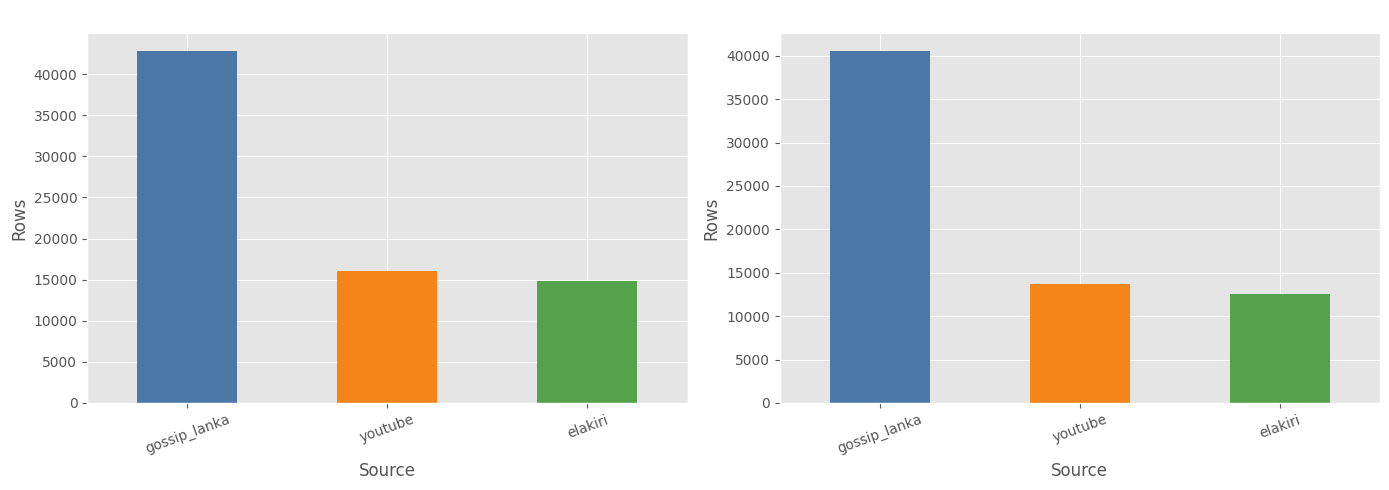

In [5]:
src_counts_cleaned = df_cleaned['source'].value_counts()
src_counts_labeled = df_labeled['source'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
src_counts_cleaned.plot(kind='bar', ax=ax[0], color=['#4C78A8', '#F58518', '#54A24B'])
ax[0].set_title('Source Distribution (Cleaned)')
ax[0].set_xlabel('Source')
ax[0].set_ylabel('Rows')
ax[0].tick_params(axis='x', rotation=20)

src_counts_labeled.plot(kind='bar', ax=ax[1], color=['#4C78A8', '#F58518', '#54A24B'])
ax[1].set_title('Source Distribution (Labeled)')
ax[1].set_xlabel('Source')
ax[1].set_ylabel('Rows')
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

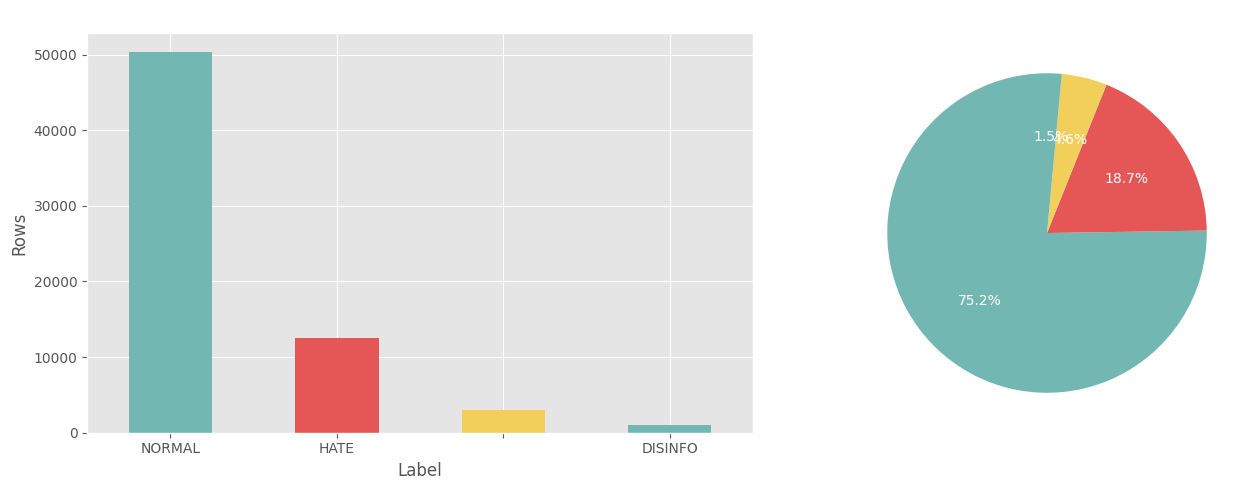

In [6]:
label_counts = df_labeled[label_col].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
label_counts.plot(kind='bar', ax=ax[0], color=['#72B7B2', '#E45756', '#F2CF5B'])
ax[0].set_title('Label Distribution (Labeled Set)')
ax[0].set_xlabel('Label')
ax[0].set_ylabel('Rows')
ax[0].tick_params(axis='x', rotation=0)

label_counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=90, colors=['#72B7B2', '#E45756', '#F2CF5B'])
ax[1].set_ylabel('')
ax[1].set_title('Label Share (%)')

plt.tight_layout()
plt.show()

annotator_label,,DISINFO,HATE,NORMAL
source,,,,
elakiri,0,150,2283,10173
gossip_lanka,3069,689,8410,28387
youtube,0,147,1800,11741


annotator_label,,DISINFO,HATE,NORMAL
source,,,,
elakiri,0.00,1.19,18.11,80.70
gossip_lanka,7.57,1.70,20.74,70.00
youtube,0.00,1.07,13.15,85.78


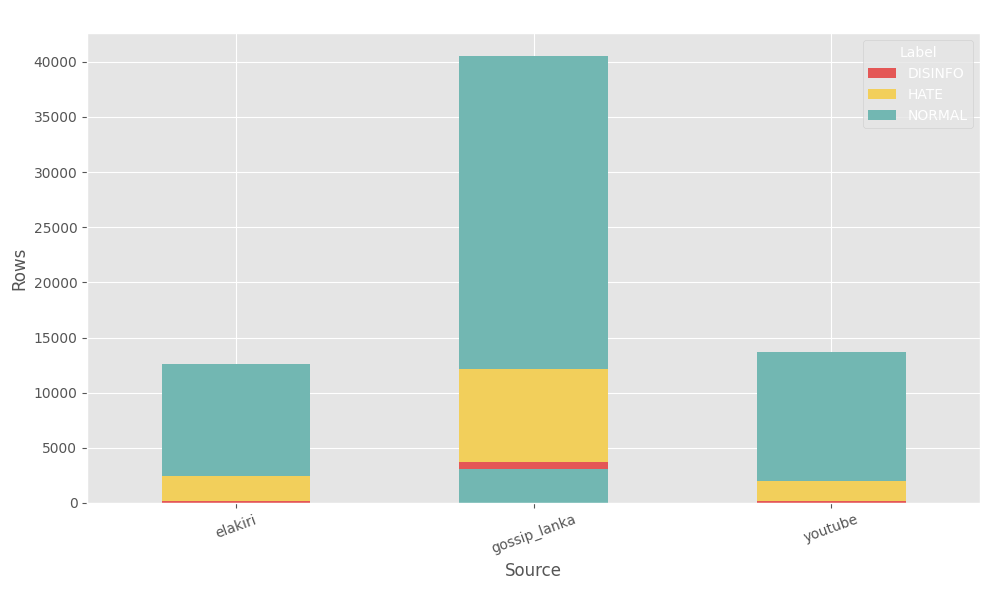

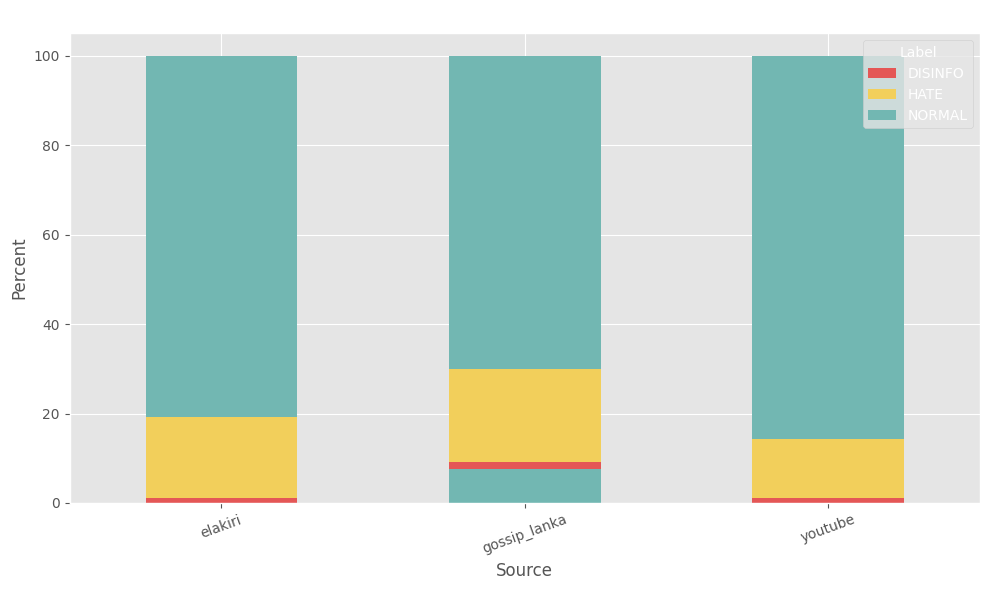

In [7]:
label_by_source = pd.crosstab(df_labeled['source'], df_labeled[label_col])
label_by_source_pct = pd.crosstab(df_labeled['source'], df_labeled[label_col], normalize='index') * 100

display(label_by_source)
display(label_by_source_pct.round(2))

ax = label_by_source.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#72B7B2', '#E45756', '#F2CF5B'])
ax.set_title('Label Distribution by Source (Stacked Count)')
ax.set_xlabel('Source')
ax.set_ylabel('Rows')
ax.tick_params(axis='x', rotation=20)
plt.legend(title='Label')
plt.tight_layout()
plt.show()

ax = label_by_source_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#72B7B2', '#E45756', '#F2CF5B'])
ax.set_title('Label Distribution by Source (Stacked %)')
ax.set_xlabel('Source')
ax.set_ylabel('Percent')
ax.tick_params(axis='x', rotation=20)
plt.legend(title='Label')
plt.tight_layout()
plt.show()

## Text-Length Analytics

In [8]:
df_cleaned['text_len'] = df_cleaned['text'].fillna('').astype(str).str.len()
df_labeled['text_len'] = df_labeled['text'].fillna('').astype(str).str.len()

length_stats = pd.DataFrame({
    'cleaned': df_cleaned['text_len'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]),
    'labeled': df_labeled['text_len'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]),
})
length_stats

,cleaned,labeled
count,73691.000000,66849.000000
mean,129.772225,131.200945
std,138.353627,138.740132
min,8.000000,8.000000
50%,81.000000,82.000000
90%,293.000000,296.000000
95%,412.000000,414.000000
99%,702.000000,701.520000
max,1197.000000,1197.000000


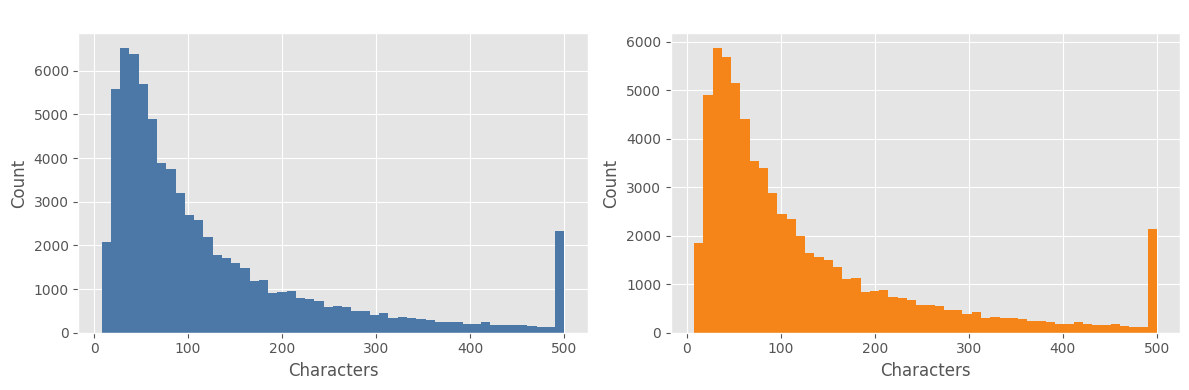

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df_cleaned['text_len'].clip(upper=500), bins=50, color='#4C78A8')
ax[0].set_title('Cleaned Text Length (Capped at 500)')
ax[0].set_xlabel('Characters')
ax[0].set_ylabel('Count')

ax[1].hist(df_labeled['text_len'].clip(upper=500), bins=50, color='#F58518')
ax[1].set_title('Labeled Text Length (Capped at 500)')
ax[1].set_xlabel('Characters')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Quality Checks

In [10]:
quality = {
    'cleaned_empty_text': int((df_cleaned['text'].fillna('').str.strip() == '').sum()),
    'labeled_empty_text': int((df_labeled['text'].fillna('').str.strip() == '').sum()),
    'labeled_unlabeled_rows': int((df_labeled[label_col] == '').sum()),
    'cleaned_duplicate_candidate_id': int(df_cleaned.duplicated(subset=['candidate_id']).sum()) if 'candidate_id' in df_cleaned.columns else np.nan,
    'labeled_duplicate_candidate_id': int(df_labeled.duplicated(subset=['candidate_id']).sum()) if 'candidate_id' in df_labeled.columns else np.nan,
}

pd.Series(quality, name='value').to_frame()

,value
cleaned_empty_text,0
labeled_empty_text,0
labeled_unlabeled_rows,3069
cleaned_duplicate_candidate_id,0
labeled_duplicate_candidate_id,0
